# Détection de Tweets Suspects — Pipeline ML Complet
### Cours : Construction de Modèles et leur Déploiement

Ce notebook traite le projet de bout en bout :

| Partie | Contenu |
|--------|---------|
| **1** | Exploration et prétraitement des données |
| **2** | Gestion des données avec DVC |
| **3** | Représentation numérique (BoW, TF-IDF, Word2Vec) |
| **4** | Construction et comparaison des modèles |
| **5** | Validation croisée et métriques |
| **6** | Optimisation des hyperparamètres + modèle final |

**Sortie finale :** `models/best_model_optimized.pkl` → utilisé par l'application Streamlit (Partie 7)

## 0. Installation et imports

In [2]:
# ── Installation des dépendances (Colab) ─────────────────────
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !pip install dvc gensim xgboost imbalanced-learn wordcloud -q

In [3]:
import warnings
warnings.filterwarnings('ignore')

# ── Standard ─────────────────────────────────────────────────
import os, re, json, time, pickle
import numpy as np
import pandas as pd
from collections import Counter

# ── Visualisation ────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud

# ── NLP ──────────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from gensim.models import Word2Vec

# ── ML ───────────────────────────────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, learning_curve,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import MaxAbsScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model  import LogisticRegression
from sklearn.naive_bayes   import MultinomialNB, ComplementNB
from sklearn.svm           import LinearSVC, SVC
from sklearn.ensemble      import RandomForestClassifier, GradientBoostingClassifier
from xgboost               import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, classification_report,
    precision_recall_curve, average_precision_score
)
from scipy.stats import loguniform, randint, uniform

# ── Équilibrage ───────────────────────────────────────────────
from imblearn.over_sampling  import SMOTE, BorderlineSMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, EditedNearestNeighbours
from imblearn.combine        import SMOTETomek, SMOTEENN

# ── NLTK resources ───────────────────────────────────────────
for r in ['stopwords', 'wordnet', 'omw-1.4', 'punkt']:
    nltk.download(r, quiet=True)

# ── Config globale ────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
os.makedirs('data',            exist_ok=True)
os.makedirs('models',          exist_ok=True)
os.makedirs('metrics',         exist_ok=True)
os.makedirs('reports/figures', exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#F8F9FA',
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11, 'axes.titlesize': 12, 'axes.titleweight': 'bold',
})
C = {'suspect': '#E74C3C', 'normal': '#2ECC71',
     'accent': '#3498DB', 'gold': '#F39C12', 'purple': '#9B59B6'}

print('Environnement prêt')
print(f'   numpy {np.__version__} | pandas {pd.__version__}')

Environnement prêt
   numpy 2.0.2 | pandas 2.2.2


# PARTIE 1 : Exploration et Prétraitement des Données

In [4]:
# ── 1.1 Chargement du dataset ─────────────────────────────────
# Sur Colab : montez votre Google Drive ou uploadez tweets.csv
# Le dataset est disponible ici :
# https://drive.google.com/file/d/1US0luOWPOeVPpUQnpyxr41zrBmeg4Gjk

DATA_PATH = 'data/tweets.csv'

# Téléchargement automatique si le fichier n'existe pas
if not os.path.exists(DATA_PATH):
    try:
        import gdown
        gdown.download(
            'https://drive.google.com/uc?id=1US0luOWPOeVPpUQnpyxr41zrBmeg4Gjk',
            DATA_PATH, quiet=False
        )
    except Exception as e:
        print(f' Téléchargement auto échoué : {e}')
        print('→ Uploadez manuellement tweets.csv dans data/')

df = pd.read_csv(DATA_PATH)

print('=' * 55)
print(f'  Dimensions  : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print(f'  Colonnes    : {df.columns.tolist()}')
print(f'  Types       :')
print(df.dtypes.to_string())
print()
df.head(8)

  Dimensions  : 60000 lignes × 2 colonnes
  Colonnes    : ['message', 'label']
  Types       :
message    object
label       int64



,message,label
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",1
1,is upset that he can't update his Facebook by ...,1
2,@Kenichan I dived many times for the ball. Man...,1
3,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all....",1
5,@Kwesidei not the whole crew,1
6,Need a hug,1
7,@LOLTrish hey long time no see! Yes.. Rains a...,1


In [5]:
# ── 1.2 Valeurs manquantes & doublons ────────────────────────
missing = df.isnull().sum()
print('Valeurs manquantes :', missing.to_dict())
n_dup = df.duplicated(subset='message').sum()
print(f'Doublons : {n_dup}')
if n_dup > 0:
    df = df.drop_duplicates(subset='message').reset_index(drop=True)
    print(f'→ Supprimés. Nouveau total : {len(df)}')

# ── Distribution des classes ──────────────────────────────────
vc = df['label'].value_counts()
print(f'\nDistribution des classes :')
print(f'  Normal  (0) : {vc[0]} ({vc[0]/len(df)*100:.1f}%)')
print(f'  Suspect (1) : {vc[1]} ({vc[1]/len(df)*100:.1f}%)')
print(f'  Ratio       : {vc[1]/vc[0]:.2f}')

Valeurs manquantes : {'message': 0, 'label': 0}
Doublons : 297
→ Supprimés. Nouveau total : 59703

Distribution des classes :
  Normal  (0) : 6130 (10.3%)
  Suspect (1) : 53573 (89.7%)
  Ratio       : 8.74


In [6]:
# ── 1.3 Features textuelles brutes ───────────────────────────
df['tweet_length']      = df['message'].apply(len)
df['word_count']        = df['message'].apply(lambda x: len(str(x).split()))
df['hashtag_count']     = df['message'].apply(lambda x: len(re.findall(r'#\w+', str(x))))
df['mention_count']     = df['message'].apply(lambda x: len(re.findall(r'@\w+', str(x))))
df['url_count']         = df['message'].apply(lambda x: len(re.findall(r'http\S+|www\.\S+', str(x))))
df['uppercase_ratio']   = df['message'].apply(lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)),1))
df['exclamation_count'] = df['message'].apply(lambda x: str(x).count('!'))
df['question_count']    = df['message'].apply(lambda x: str(x).count('?'))

print('Features extraites :')
display_cols = ['tweet_length','word_count','hashtag_count',
                'mention_count','url_count','uppercase_ratio','exclamation_count']
print(df.groupby('label')[display_cols].mean().round(3).to_string())

Features extraites :
       tweet_length  word_count  hashtag_count  mention_count  url_count  uppercase_ratio  exclamation_count
label                                                                                                       
0            86.640      15.570          0.025          0.384      0.036            0.041              0.569
1            72.406      12.846          0.022          0.485      0.045            0.044              0.535


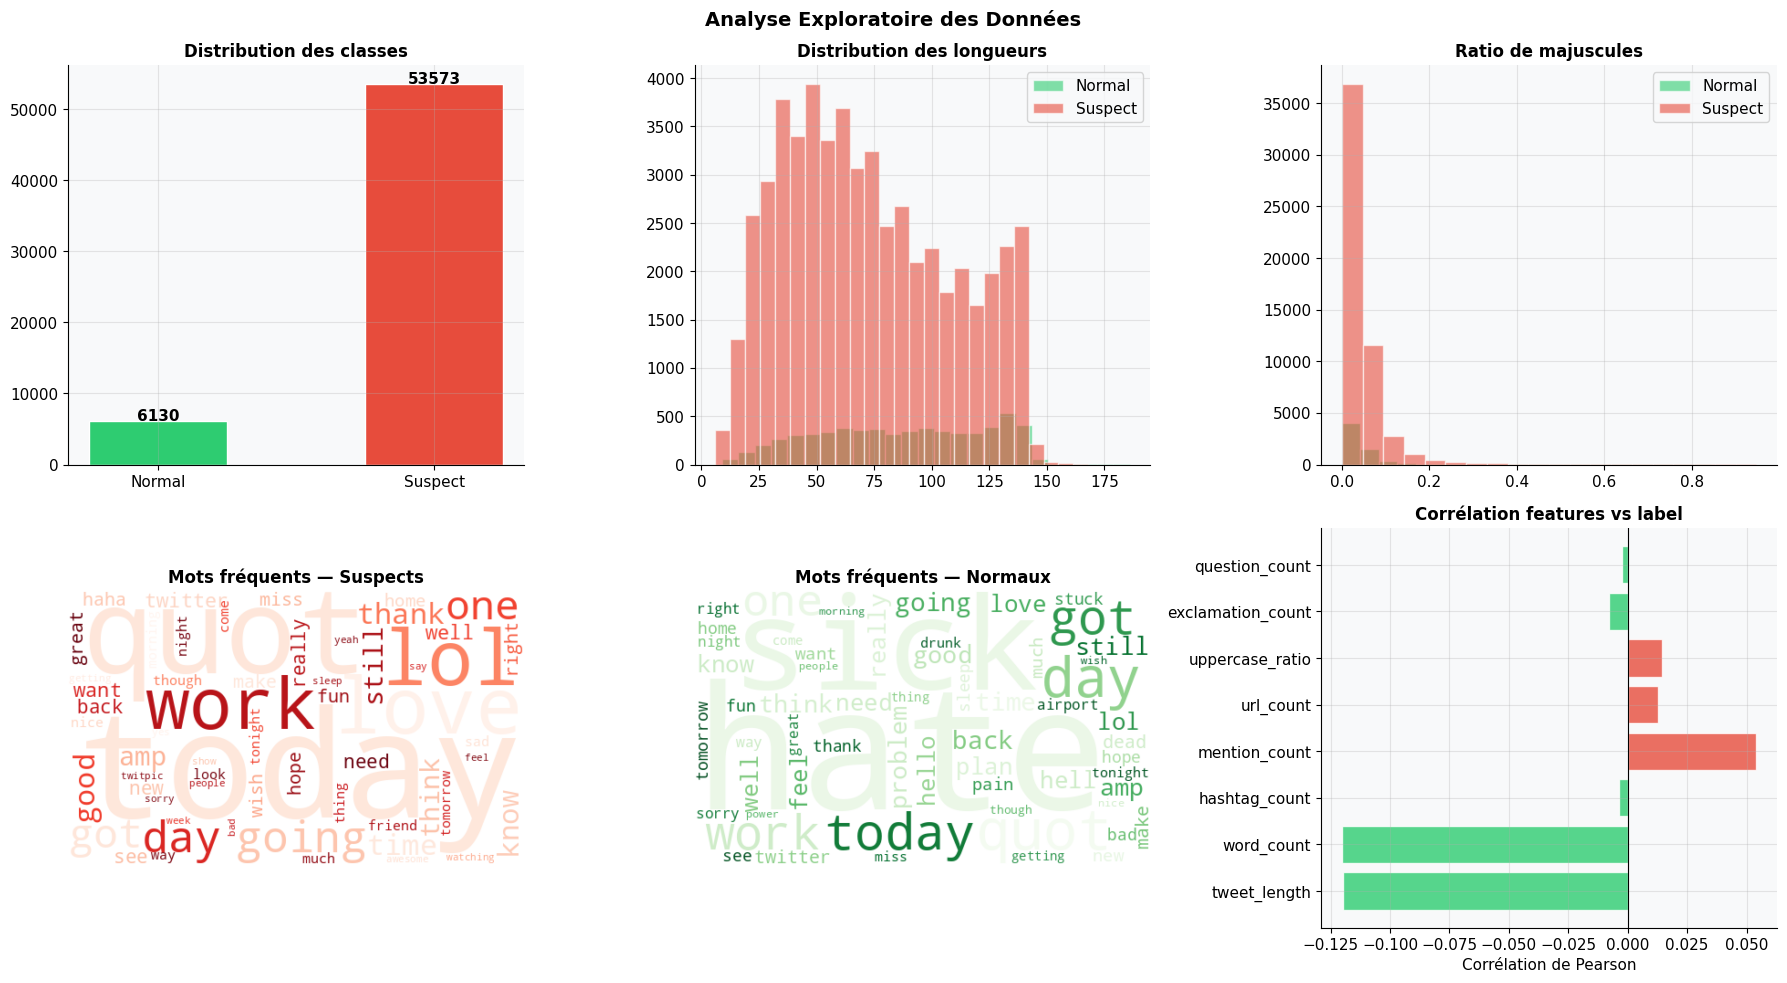

Figure EDA sauvegardée


In [7]:
# ── 1.4 Visualisations EDA ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Analyse Exploratoire des Données', fontsize=14, fontweight='bold')

# Distribution des classes
ax = axes[0, 0]
bars = ax.bar(['Normal', 'Suspect'], [vc[0], vc[1]],
               color=[C['normal'], C['suspect']], edgecolor='white', width=0.5)
for bar, cnt in zip(bars, [vc[0], vc[1]]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{cnt}', ha='center', fontweight='bold')
ax.set_title('Distribution des classes')

# Longueur des tweets
ax = axes[0, 1]
for lbl, color, name in [(0,C['normal'],'Normal'),(1,C['suspect'],'Suspect')]:
    ax.hist(df[df['label']==lbl]['tweet_length'], bins=25,
            alpha=0.6, color=color, label=name, edgecolor='white')
ax.set_title('Distribution des longueurs'); ax.legend()

# Ratio majuscules
ax = axes[0, 2]
for lbl, color, name in [(0,C['normal'],'Normal'),(1,C['suspect'],'Suspect')]:
    ax.hist(df[df['label']==lbl]['uppercase_ratio'], bins=20,
            alpha=0.6, color=color, label=name, edgecolor='white')
ax.set_title('Ratio de majuscules'); ax.legend()

# Word cloud suspects
sw = set(stopwords.words('english'))
def cloud_text(texts):
    words = []
    for t in texts:
        toks = re.sub(r'[^a-z ]', ' ', str(t).lower()).split()
        words.extend([w for w in toks if w not in sw and len(w)>2])
    return ' '.join(words)

ax = axes[1, 0]
wc = WordCloud(width=500, height=300, background_color='white',
               colormap='Reds', max_words=60, random_state=RANDOM_STATE)
wc.generate(cloud_text(df[df['label']==1]['message']))
ax.imshow(wc, interpolation='bilinear'); ax.axis('off')
ax.set_title('Mots fréquents — Suspects')

# Word cloud normaux
ax = axes[1, 1]
wc2 = WordCloud(width=500, height=300, background_color='white',
                colormap='Greens', max_words=60, random_state=RANDOM_STATE)
wc2.generate(cloud_text(df[df['label']==0]['message']))
ax.imshow(wc2, interpolation='bilinear'); ax.axis('off')
ax.set_title('Mots fréquents — Normaux')

# Corrélation features vs label
ax = axes[1, 2]
feat_cols = ['tweet_length','word_count','hashtag_count','mention_count',
             'url_count','uppercase_ratio','exclamation_count','question_count']
corr_vals = [df[f].corr(df['label']) for f in feat_cols]
colors_corr = [C['suspect'] if v>0 else C['normal'] for v in corr_vals]
ax.barh(feat_cols, corr_vals, color=colors_corr, alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Corrélation features vs label')
ax.set_xlabel('Corrélation de Pearson')

plt.tight_layout()
plt.savefig('reports/figures/p1_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure EDA sauvegardée')

In [8]:
# ── 1.5 Pipeline de prétraitement ────────────────────────────
PRESERVE_NEGATIONS = {
    'no','not','never','nothing','nobody','nowhere',
    'none','nor','neither','cannot',"can't","won't",
    'against','hate','bad','worst'
}
lemmatizer  = WordNetLemmatizer()
STOP_WORDS  = set(stopwords.words('english')) - PRESERVE_NEGATIONS

def preprocess_tweet(text):
    """
    Pipeline :
      1. Minuscules
      2. Suppression URLs
      3. Suppression mentions @
      4. Nettoyage hashtags (#mot → mot)
      5. Suppression caractères spéciaux
      6. Normalisation espaces
      7. Suppression stop words (négations préservées)
      8. Lemmatisation (verbes + noms)
    """
    if pd.isna(text): return ''
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [t for t in text.split() if t not in STOP_WORDS and len(t) > 1]
    tokens = [lemmatizer.lemmatize(t, pos='v') for t in tokens]
    tokens = [lemmatizer.lemmatize(t, pos='n') for t in tokens]
    return ' '.join(tokens)

# Démonstration
exemples = [
    "@user BREAKING: fake news spreading!! http://scam.ru click here NOW!!!",
    "Just had the most amazing breakfast this morning :)",
]
print('Démonstration du prétraitement :')
for ex in exemples:
    print(f'  AVANT : {ex}')
    print(f'  APRÈS : {preprocess_tweet(ex)}')
    print()

Démonstration du prétraitement :
  AVANT : @user BREAKING: fake news spreading!! http://scam.ru click here NOW!!!
  APRÈS : break fake news spread click

  AVANT : Just had the most amazing breakfast this morning :)
  APRÈS : amaze breakfast morning



In [9]:
# ── 1.6 Application du prétraitement ─────────────────────────
print('Prétraitement en cours...')
t0 = time.time()
df['message_clean'] = df['message'].apply(preprocess_tweet)
df['clean_word_count'] = df['message_clean'].apply(lambda x: len(str(x).split()))
print(f'Terminé en {time.time()-t0:.1f}s')

# Supprimer les tweets vides après nettoyage
n_before = len(df)
df = df[df['message_clean'].str.strip() != ''].reset_index(drop=True)
print(f'Tweets vides supprimés : {n_before - len(df)} | Total : {len(df)}')

# Sauvegarde
df.to_csv('data/tweets_preprocessed.csv', index=False)
print('data/tweets_preprocessed.csv sauvegardé')

print(f'\nMots/tweet AVANT : {df["word_count"].mean():.1f}')
print(f'Mots/tweet APRÈS : {df["clean_word_count"].mean():.1f}')
df[['message','message_clean','label']].head(5)

Prétraitement en cours...
Terminé en 13.9s
Tweets vides supprimés : 271 | Total : 59432
data/tweets_preprocessed.csv sauvegardé

Mots/tweet AVANT : 13.2
Mots/tweet APRÈS : 7.0


,message,message_clean,label
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww bummer shoulda get david carr third day,1
1,is upset that he can't update his Facebook by ...,upset update facebook texting might cry result...,1
2,@Kenichan I dived many times for the ball. Man...,dive many time ball manage save rest go bound,1
3,my whole body feels itchy and like its on fire,whole body feel itchy like fire,0
4,"@nationwideclass no, it's not behaving at all....",no not behave mad see,1


# PARTIE 2 : Gestion des Données avec DVC

In [10]:
# ── 2.1 Initialisation Git + DVC ─────────────────────────────
# À exécuter UNE SEULE FOIS dans le dossier projet
import subprocess

def run(cmd, check=False):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    out = r.stdout.strip() or r.stderr.strip()
    if out: print(out)
    return r.returncode

print('=== Initialisation Git ===')
run('git init')
run('git config user.email "etudiant@projet.ml"')
run('git config user.name "Etudiant ML"')

print('\n=== Initialisation DVC ===')
run('dvc init')

print('\n=== Configuration remote DVC (local) ===')
os.makedirs('dvc_storage', exist_ok=True)
run('dvc remote add -d localremote dvc_storage')
print('Remote configuré : dvc_storage/')

=== Initialisation Git ===
Reinitialized existing Git repository in /content/.git/

=== Initialisation DVC ===
ERROR: failed to initiate DVC - '.dvc' exists. Use `-f` to force.

=== Configuration remote DVC (local) ===
Setting 'localremote' as a default remote.
Remote configuré : dvc_storage/


In [11]:
# ── 2.2 Versionnement du dataset ──────────────────────────────
print('=== Versionnement DVC ===')
run('dvc add data/tweets.csv')

print('\n=== Premier commit Git ===')
run('git add .')
run('git commit -m "init: Git + DVC + dataset versionné"')

print('\n=== Push vers remote DVC ===')
run('dvc push')

print('\n=== Statut DVC ===')
run('dvc status')

# Afficher le fichier .dvc généré
if os.path.exists('data/tweets.csv.dvc'):
    print('\n--- Contenu de data/tweets.csv.dvc ---')
    with open('data/tweets.csv.dvc') as f:
        print(f.read())

=== Versionnement DVC ===
To track the changes with git, run:

	git add data/tweets.csv.dvc

To enable auto staging, run:

	dvc config core.autostage true

=== Premier commit Git ===
[master a8e6798] init: Git + DVC + dataset versionné
 5 files changed, 60032 insertions(+)
 create mode 100644 dvc.yaml
 create mode 100644 dvc_storage/files/md5/60/e5f26c964cb0a766047fd993102170
 create mode 100644 params.yaml
 create mode 100644 reports/figures/p3_representations.png
 create mode 100644 reports/figures/p4_modeles.png

=== Push vers remote DVC ===
Everything is up to date.

=== Statut DVC ===
preprocess:
	changed deps:
		deleted:            src/preprocess.py
		modified:           data/tweets.csv
		new:                params.yaml
	changed outs:
		modified:           data/tweets_preprocessed.csv
train:
	changed deps:
		deleted:            src/train.py
		modified:           data/tweets_preprocessed.csv
		new:                params.yaml
	changed outs:
		deleted:            models/best_model_o

In [12]:
# ── 2.3 Pipeline DVC (dvc.yaml) ───────────────────────────────
# Ce fichier documente les étapes du pipeline pour la reproductibilité.
# Dans un vrai projet : dvc repro rejoue tout automatiquement.
# Ici, les étapes sont exécutées directement dans ce notebook.

dvc_yaml = """
stages:
  preprocess:
    cmd: python src/preprocess.py
    deps: [src/preprocess.py, data/tweets.csv]
    params: [params.yaml]
    outs: [data/tweets_preprocessed.csv]

  train:
    cmd: python src/train.py
    deps: [src/train.py, data/tweets_preprocessed.csv]
    params: [params.yaml]
    outs: [models/best_model_optimized.pkl]
    metrics: [metrics/metrics.json]
"""

with open('dvc.yaml', 'w') as f:
    f.write(dvc_yaml)

params_yaml = """
preprocess:
  language: english
  lemmatize: true
  preserve_negations: true

vectorizer:
  max_features: 10000
  ngram_range: [1, 2]
  sublinear_tf: true
  min_df: 2

train:
  test_size: 0.2
  random_state: 42
  cv_folds: 5
  class_weight: balanced
"""

with open('params.yaml', 'w') as f:
    f.write(params_yaml)

print('dvc.yaml et params.yaml créés')
print('\nPour reproduire depuis zéro :')
print('  dvc pull     → récupère les données')
print('  dvc repro    → rejoue tout le pipeline')

dvc.yaml et params.yaml créés

Pour reproduire depuis zéro :
  dvc pull     → récupère les données
  dvc repro    → rejoue tout le pipeline


# PARTIE 3 : Représentation Numérique des Données

In [13]:
# ── 3.1 Split train/test (définitif pour tout le notebook) ────
corpus = df['message_clean'].tolist()
labels = df['label'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    corpus, labels, test_size=0.2,
    random_state=RANDOM_STATE, stratify=labels
)
print(f'Train : {len(X_train_raw)} | Test : {len(X_test_raw)}')
print(f'Suspects train : {y_train.sum()} | Normaux train : {(y_train==0).sum()}')

Train : 47545 | Test : 11887
Suspects train : 42641 | Normaux train : 4904


In [14]:
# ── 3.2 Bag of Words ─────────────────────────────────────────
bow_vec = CountVectorizer(max_features=5000, ngram_range=(1,1), min_df=2)
bow_vec.fit(X_train_raw)
X_bow_train = bow_vec.transform(X_train_raw)
X_bow_test  = bow_vec.transform(X_test_raw)
print(f'BoW  → {X_bow_train.shape} | vocab={len(bow_vec.vocabulary_)}')

# ── 3.3 TF-IDF ───────────────────────────────────────────────
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2),
                         sublinear_tf=True, min_df=2)
tfidf.fit(X_train_raw)
X_train = tfidf.transform(X_train_raw)
X_test  = tfidf.transform(X_test_raw)
X_train_d = X_train.toarray()
X_test_d  = X_test.toarray()
print(f'TFIDF → {X_train.shape} | vocab={len(tfidf.vocabulary_)}')

# ── 3.4 Word2Vec ─────────────────────────────────────────────
sentences_train = [t.split() for t in X_train_raw]
sentences_all   = [t.split() for t in corpus]
w2v_model = Word2Vec(sentences=sentences_train, vector_size=100,
                      window=5, min_count=2, sg=1, epochs=30,
                      workers=4, seed=RANDOM_STATE)
print(f'W2V  → vocab={len(w2v_model.wv)} | dim=100')

def tweet_to_vec(tokens, model, dim=100):
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

X_w2v_train = np.vstack([tweet_to_vec(t.split(), w2v_model) for t in X_train_raw])
X_w2v_test  = np.vstack([tweet_to_vec(t.split(), w2v_model) for t in X_test_raw])
print(f'W2V matrice train → {X_w2v_train.shape}')

BoW  → (47545, 5000) | vocab=5000
TFIDF → (47545, 10000) | vocab=10000
W2V  → vocab=11249 | dim=100
W2V matrice train → (47545, 100)


Calcul t-SNE...


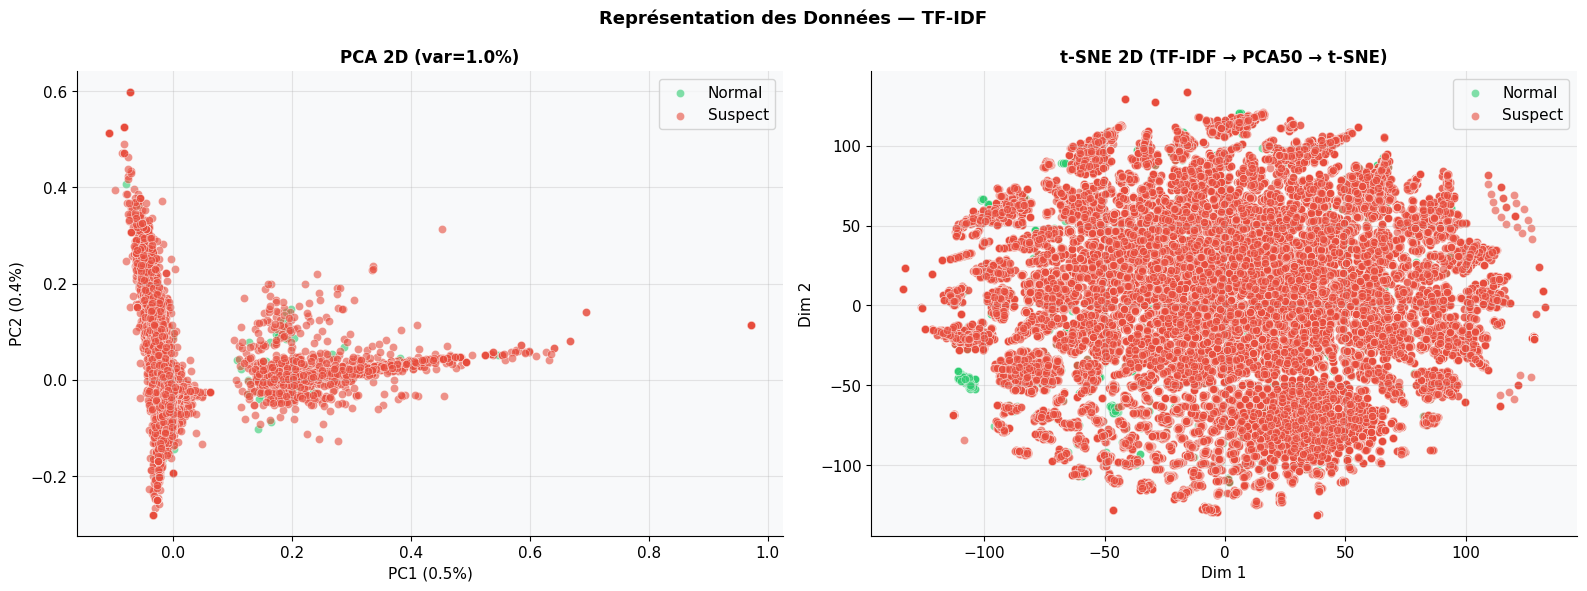

Figure sauvegardée


In [15]:
# ── 3.5 Visualisation t-SNE ──────────────────────────────────
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# PCA 50D avant t-SNE (plus stable)
pca = PCA(n_components=min(50, X_train_d.shape[1]-1), random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_train_d)

print('Calcul t-SNE...')
tsne = TSNE(n_components=2, perplexity=min(20, len(X_train_raw)//5),
             max_iter=1000, random_state=RANDOM_STATE, init='pca')
X_2d = tsne.fit_transform(X_pca)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Représentation des Données — TF-IDF', fontsize=13, fontweight='bold')

# PCA 2D
ax = axes[0]
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca2.fit_transform(X_train_d)
for lbl, col, name in [(0,C['normal'],'Normal'),(1,C['suspect'],'Suspect')]:
    m = y_train == lbl
    ax.scatter(X_pca2[m,0], X_pca2[m,1], c=col, alpha=0.6, s=35,
               label=name, edgecolors='white', linewidth=0.4)
ev = pca2.explained_variance_ratio_
ax.set_title(f'PCA 2D (var={ev.sum()*100:.1f}%)')
ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}%)'); ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}%)')
ax.legend()

# t-SNE
ax = axes[1]
for lbl, col, name in [(0,C['normal'],'Normal'),(1,C['suspect'],'Suspect')]:
    m = y_train == lbl
    ax.scatter(X_2d[m,0], X_2d[m,1], c=col, alpha=0.6, s=35,
               label=name, edgecolors='white', linewidth=0.4)
ax.set_title('t-SNE 2D (TF-IDF → PCA50 → t-SNE)')
ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2'); ax.legend()

plt.tight_layout()
plt.savefig('reports/figures/p3_representations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée')

### Évaluation du Random Forest avec Réduction de Dimension (PCA)
Pour accélérer l'entraînement sur les 47k tweets, nous appliquons une PCA pour réduire la dimensionnalité de la matrice TF-IDF avant de passer les données au Random Forest.

In [16]:
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

# 1. Réduction de dimension avec PCA
# On réduit à 100 composantes pour garder l'essentiel de la variance
n_comp = 100
pca_rf = PCA(n_components=n_comp, random_state=RANDOM_STATE)

print(f'Application de la PCA ({n_comp} composantes)...')
X_train_pca = pca_rf.fit_transform(X_train_d)
X_test_pca = pca_rf.transform(X_test_d)

# 2. Entraînement du Random Forest
rf_pca = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                n_jobs=-1, random_state=RANDOM_STATE)

print('Entraînement du Random Forest sur données compressées...')
t0 = time.time()
rf_pca.fit(X_train_pca, y_train)
duration = time.time() - t0

# 3. Évaluation
y_pred_rf = rf_pca.predict(X_test_pca)
f1_rf = f1_score(y_test, y_pred_rf)

print(f'Terminé en {duration:.2f}s')
print(f'F1-Score avec PCA : {f1_rf:.4f}')
print(f'Variance expliquée cumulée : {pca_rf.explained_variance_ratio_.sum():.4f}')

Application de la PCA (100 composantes)...
Entraînement du Random Forest sur données compressées...
Terminé en 58.80s
F1-Score avec PCA : 0.9562
Variance expliquée cumulée : 0.1859


In [17]:
# ── 3.6 Comparaison rapide des représentations ────────────────
from sklearn.linear_model import LogisticRegression as LR

repr_results = {}
for name, Xtr, Xte in [
    ('Bag of Words',   X_bow_train, X_bow_test),
    ('TF-IDF (1-2g)',  X_train,     X_test),
    ('Word2Vec',       X_w2v_train, X_w2v_test),
]:
    clf = LR(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
    clf.fit(Xtr, y_train)
    y_pred = clf.predict(Xte)
    f1  = f1_score(y_test, y_pred, zero_division=0)
    acc = accuracy_score(y_test, y_pred)
    repr_results[name] = {'f1': round(f1,4), 'accuracy': round(acc,4)}
    print(f'{name:<20} F1={f1:.4f} | Acc={acc:.4f}')

best_repr = max(repr_results, key=lambda k: repr_results[k]['f1'])
print(f'\n→ Représentation retenue : {best_repr} (F1={repr_results[best_repr]["f1"]:.4f})')
print('  TF-IDF retenu pour la suite (meilleur F1, bigrammes discriminants)')

Bag of Words         F1=0.9808 | Acc=0.9657
TF-IDF (1-2g)        F1=0.9829 | Acc=0.9694
Word2Vec             F1=0.8175 | Acc=0.7125

→ Représentation retenue : TF-IDF (1-2g) (F1=0.9829)
  TF-IDF retenu pour la suite (meilleur F1, bigrammes discriminants)


# PARTIE 4 : Construction et Comparaison des Modèles

In [18]:
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.combine import SMOTETomek
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

# ── 4.1 Stratégies d'équilibrage ─────────────────────────────
# Dataset réel : ~47k tweets, fortement déséquilibré (ratio ~1:9)
# On garde les stratégies les plus efficaces sur grands datasets

balancing_strategies = {
    'Baseline'            : None,
    'Class Weights'       : 'class_weight',        # le plus rapide
    'SMOTE'               : SMOTE(random_state=RANDOM_STATE, k_neighbors=5),
    'Random Oversampling' : RandomOverSampler(random_state=RANDOM_STATE),
    'Random UnderSampling': RandomUnderSampler(random_state=RANDOM_STATE),
    'TomekLinks'          : TomekLinks(),
    'SMOTETomek'          : SMOTETomek(random_state=RANDOM_STATE),
}

def get_models(use_cw=False):
    cw = 'balanced' if use_cw else None
    return {
        'Logistic Regression' : LogisticRegression(C=1.0, max_iter=1000,
                                    class_weight=cw, random_state=RANDOM_STATE),
        'Naive Bayes (MNB)'   : MultinomialNB(alpha=0.1),
        'Naive Bayes (CNB)'   : ComplementNB(alpha=0.1),
        'SVM Linear'          : LinearSVC(C=1.0, max_iter=2000,
                                    class_weight=cw, random_state=RANDOM_STATE),
        # Random Forest est retiré ici pour être testé séparément avec PCA
        'XGBoost'             : XGBClassifier(n_estimators=100,
                                    eval_metric='logloss', verbosity=0,
                                    random_state=RANDOM_STATE),
    }

# SVM RBF et Gradient Boosting retirés :
# sur 47k tweets × matrice dense → des heures d'exécution
# SVM Linear est suffisant et beaucoup plus rapide

DENSE_MODELS = {'XGBoost'}

print(f' {len(balancing_strategies)} stratégies × {len(get_models())} modèles')
print(f'   Combinaisons : {len(balancing_strategies) * len(get_models())}')
print()
print('  Note : Random Forest, SVM RBF et Gradient Boosting exclus de la boucle principale')
print('  pour optimiser le temps de calcul.')

 7 stratégies × 5 modèles
   Combinaisons : 35

  Note : Random Forest, SVM RBF et Gradient Boosting exclus de la boucle principale
  pour optimiser le temps de calcul.


In [19]:
# ── 4.2 Évaluation de toutes les combinaisons ─────────────────
import scipy.sparse as sp

all_results = []

for strat_name, sampler in balancing_strategies.items():
    use_cw = (sampler == 'class_weight')
    models = get_models(use_cw=use_cw)

    if sampler is None or use_cw:
        X_tr_bal, y_tr_bal = X_train, y_train
    else:
        X_tr_bal, y_tr_bal = sampler.fit_resample(X_train, y_train)

    counts = np.bincount(y_tr_bal)
    bal_info = f'{counts[0]}N/{counts[1]}S'
    print(f'\n  [{strat_name}] — {bal_info}')
    print(f'  {"-"*65}')

    for model_name, model in models.items():
        needs_dense = model_name in DENSE_MODELS
        Xtr = X_tr_bal.toarray() if needs_dense and sp.issparse(X_tr_bal) else X_tr_bal
        Xte = X_test.toarray()   if needs_dense and sp.issparse(X_test)   else X_test

        try:
            t0 = time.time()
            model.fit(Xtr, y_tr_bal)
            y_pred = model.predict(Xte)
            try:
                proba = model.predict_proba(Xte)[:, 1]
            except AttributeError:
                raw   = model.decision_function(Xte)
                proba = (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)

            res = {
                'strategy' : strat_name,
                'model'    : model_name,
                'bal_counts': bal_info,
                'f1'       : round(f1_score(y_test, y_pred, zero_division=0), 4),
                'auc'      : round(roc_auc_score(y_test, proba), 4),
                'accuracy' : round(accuracy_score(y_test, y_pred), 4),
                'precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
                'recall'   : round(recall_score(y_test, y_pred, zero_division=0), 4),
                'train_s'  : round(time.time() - t0, 2),
            }
            all_results.append(res)
            print(f'    {model_name:<25}  F1={res["f1"]:.4f}  '
                  f'AUC={res["auc"]:.4f}  Acc={res["accuracy"]:.4f}  ({res["train_s"]}s)')
        except Exception as e:
            print(f'    {model_name:<25}  ❌ {str(e)[:60]}')

results_df = pd.DataFrame(all_results).sort_values('f1', ascending=False).reset_index(drop=True)
print(f'\n {len(results_df)} combinaisons évaluées')
print(f'\nTop 10 :')
print(results_df[['strategy','model','f1','auc','accuracy','train_s']].head(10).to_string())


  [Baseline] — 4904N/42641S
  -----------------------------------------------------------------
    Logistic Regression        F1=0.9733  AUC=0.9425  Acc=0.9509  (0.19s)
    Naive Bayes (MNB)          F1=0.9691  AUC=0.9136  Acc=0.9429  (0.02s)
    Naive Bayes (CNB)          F1=0.9018  AUC=0.9136  Acc=0.8368  (0.03s)
    SVM Linear                 F1=0.9866  AUC=0.9413  Acc=0.9758  (0.14s)
    XGBoost                    F1=0.9833  AUC=0.9027  Acc=0.9696  (113.51s)

  [Class Weights] — 4904N/42641S
  -----------------------------------------------------------------
    Logistic Regression        F1=0.9829  AUC=0.9424  Acc=0.9694  (0.12s)
    Naive Bayes (MNB)          F1=0.9691  AUC=0.9136  Acc=0.9429  (0.02s)
    Naive Bayes (CNB)          F1=0.9018  AUC=0.9136  Acc=0.8368  (0.02s)
    SVM Linear                 F1=0.9799  AUC=0.9388  Acc=0.9640  (0.19s)
    XGBoost                    F1=0.9833  AUC=0.9027  Acc=0.9696  (114.49s)

  [SMOTE] — 42641N/42641S
  ----------------------------

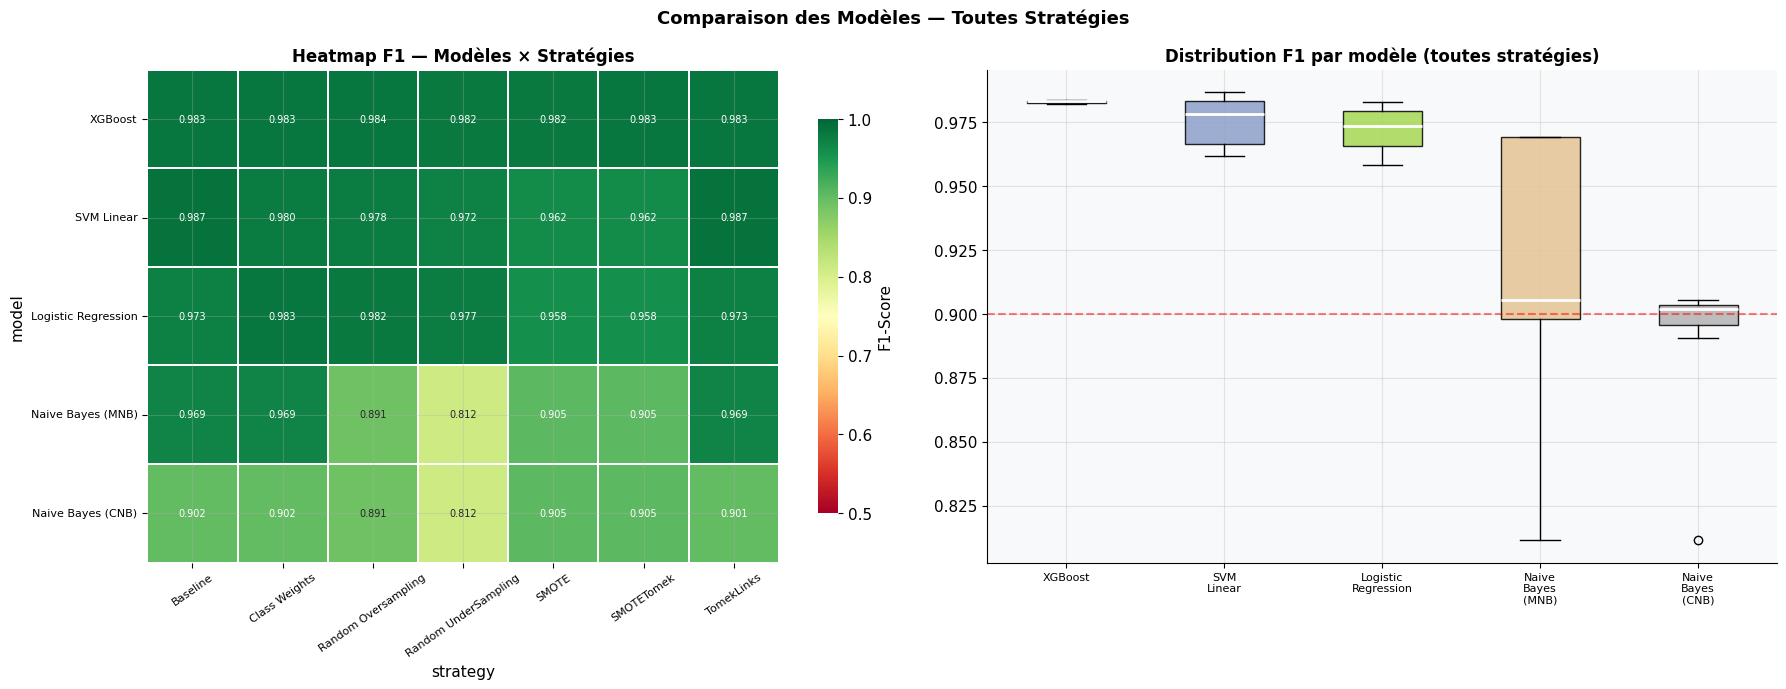

Figure sauvegardée

 Meilleure combinaison Partie 4 :
   Modèle    : SVM Linear
   Stratégie : TomekLinks
   F1=0.9867 | AUC=0.9409


In [20]:
# ── 4.3 Visualisations comparatives ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Comparaison des Modèles — Toutes Stratégies', fontsize=13, fontweight='bold')

# Heatmap F1
pivot = results_df.pivot_table(values='f1', index='model',
                                columns='strategy', aggfunc='max')
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.5, vmax=1.0, ax=axes[0],
            linewidths=0.3, annot_kws={'size': 7},
            cbar_kws={'label': 'F1-Score', 'shrink': 0.8})
axes[0].set_title('Heatmap F1 — Modèles × Stratégies')
axes[0].tick_params(axis='x', rotation=35, labelsize=8)
axes[0].tick_params(axis='y', rotation=0, labelsize=8)

# Boxplots F1 par modèle
model_order = results_df.groupby('model')['f1'].median().sort_values(ascending=False).index
data_boxes  = [results_df[results_df['model']==m]['f1'].values for m in model_order]
bp = axes[1].boxplot(data_boxes, patch_artist=True,
                      medianprops={'color':'white','linewidth':2})
palette = plt.cm.Set2(np.linspace(0,1,len(model_order)))
for patch, col in zip(bp['boxes'], palette):
    patch.set_facecolor(col); patch.set_alpha(0.85)
axes[1].set_xticks(range(1, len(model_order)+1))
axes[1].set_xticklabels([m.replace(' ','\n') for m in model_order], fontsize=8)
axes[1].set_title('Distribution F1 par modèle (toutes stratégies)')
axes[1].axhline(0.9, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('reports/figures/p4_modeles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée')

best_p4 = results_df.iloc[0]
print(f'\n Meilleure combinaison Partie 4 :')
print(f'   Modèle    : {best_p4["model"]}')
print(f'   Stratégie : {best_p4["strategy"]}')
print(f'   F1={best_p4["f1"]:.4f} | AUC={best_p4["auc"]:.4f}')

# PARTIE 5 : Entraînement et Validation

In [21]:
import time
import numpy as np
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ── 5.1 Configuration de la Validation Croisée ───────────────────
RANDOM_STATE = 42
CV_FOLDS = 10
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
# Initialisation globale pour stocker les résultats de chaque cellule
cv_results = {}

print(f'Validation croisée {CV_FOLDS}-Fold configurée.')
print(f'Prêt à évaluer les modèles individuellement.')

Validation croisée 10-Fold configurée.
Prêt à évaluer les modèles individuellement.


In [22]:
# ── 5.1.1 Logistic Regression ──────────────────────────────────
name = 'Logistic Regression'
model = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)

print(f'Évaluation de {name}...')
scores = cross_validate(model, X_train, y_train, cv=skf,
                        scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
                        n_jobs=-1, return_train_score=True)

cv_results[name] = scores
print(f"  F1: {scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}")
print(f"  AUC: {scores['test_roc_auc'].mean():.4f}")

Évaluation de Logistic Regression...
  F1: 0.9835 ± 0.0009
  AUC: 0.9540


In [23]:
# ── 5.1.2 SVM Linear ───────────────────────────────────────────
name = 'SVM Linear'
model = LinearSVC(C=1.0, max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)

print(f'Évaluation de {name}...')
# Note: LinearSVC n'a pas de predict_proba par défaut, donc pas de roc_auc simple ici
scores = cross_validate(model, X_train, y_train, cv=skf,
                        scoring=['accuracy', 'precision', 'recall', 'f1'],
                        n_jobs=-1, return_train_score=True)

cv_results[name] = scores
print(f"  F1: {scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}")

Évaluation de SVM Linear...
  F1: 0.9800 ± 0.0013


In [24]:
# ── 5.1.3 Naive Bayes (MNB) ───────────────────────────
name = 'Naive Bayes (MNB)'
model = MultinomialNB(alpha=0.1)

print(f'Évaluation de {name}...')
scores = cross_validate(model, X_train, y_train, cv=skf,
                        scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
                        n_jobs=-1, return_train_score=True)

cv_results[name] = scores
print(f"  F1: {scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}")
print(f"  AUC: {scores['test_roc_auc'].mean():.4f}")

Évaluation de Naive Bayes (MNB)...
  F1: 0.9678 ± 0.0015
  AUC: 0.9193


In [2]:
# ── 5.1.5 XGBoost ────────────────────────────────
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate
import numpy as np

name = 'XGBoost'
model = XGBClassifier(n_estimators=100, eval_metric='logloss', verbosity=0, random_state=RANDOM_STATE)

print(f'Évaluation de {name}...')

# S'assurer que la version dense est disponible
try:
    X_train_dense = X_train_d
except NameError:
    X_train_dense = X_train.toarray()

# Correction : n_jobs=1 pour éviter l'erreur d'espace disque (PicklingError/OSError 28)
scores = cross_validate(model, X_train_dense, y_train, cv=skf,
                        scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
                        n_jobs=1, return_train_score=True)

cv_results[name] = scores
print(f"  F1: {scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}")
if 'test_roc_auc' in scores:
    print(f"  AUC: {scores['test_roc_auc'].mean():.4f}")

NameError: name 'RANDOM_STATE' is not defined

In [1]:
# ── 5.2 Synthèse des résultats de Validation Croisée (μ ± σ) ──────────
import numpy as np

print('Synthèse de la Validation Croisée')
print('=' * 65)
print(f'  {"Modèle":<25} {"F1-Score":>15} {"AUC-ROC":>15}')
print('  ' + '-' * 60)

# Tri des modèles par F1-score moyen décroissant
sorted_results = sorted(cv_results.items(), key=lambda x: x[1]['test_f1'].mean(), reverse=True)

for name, scores in sorted_results:
    f1_mean = scores['test_f1'].mean()
    f1_std  = scores['test_f1'].std()

    # Gestion des modèles sans probabilités (ex: LinearSVC)
    if 'test_roc_auc' in scores:
        auc_mean = scores['test_roc_auc'].mean()
        auc_str = f"{auc_mean:.4f}"
    else:
        auc_str = "N/A"

    print(f'  {name:<25} {f1_mean:.4f} ± {f1_std:.4f}  {auc_str:>12}')

Synthèse de la Validation Croisée
  Modèle                           F1-Score         AUC-ROC
  ------------------------------------------------------------


NameError: name 'cv_results' is not defined

# PARTIE 6 : Optimisation des Hyperparamètres

In [ ]:
# ── 6.1 Grid Search ──────────────────────────────────────────
# Sur 47k tweets : grilles réduites pour rester < 30 min
# SVM RBF sur un sous-échantillon représentatif

CV5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Sous-échantillon pour SVM RBF (qui ne scale pas sur grands datasets)
N_SAMPLE = 5000
idx_sample = np.concatenate([
    np.where(y_train == 0)[0][:N_SAMPLE//2],
    np.where(y_train == 1)[0][:N_SAMPLE//2]
])
np.random.shuffle(idx_sample)
X_train_sample   = X_train[idx_sample]
X_train_sample_d = X_train_sample.toarray()
y_train_sample   = y_train[idx_sample]

grid_configs = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, class_weight='balanced',
                                     random_state=RANDOM_STATE),
        'X': X_train, 'X_te': X_test,
        'grid': {
            'C'     : [0.01, 0.1, 1.0, 10.0, 100.0],
            'solver': ['lbfgs', 'saga'],
        }
    },
    'Naive Bayes (MNB)': {
        'model': MultinomialNB(),
        'X': X_train, 'X_te': X_test,
        'grid': {'alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 2.0]}
    },
    'SVM Linear': {
        'model': LinearSVC(max_iter=3000, class_weight='balanced',
                            random_state=RANDOM_STATE),
        'X': X_train, 'X_te': X_test,
        'grid': {
            'C'   : [0.01, 0.1, 1.0, 10.0],
            'loss': ['hinge', 'squared_hinge'],
        }
    },
    'SVM RBF (sample 5k)': {
        # Évalué sur sous-échantillon équilibré de 5000 tweets
        'model': SVC(kernel='rbf', probability=True, class_weight='balanced',
                      random_state=RANDOM_STATE),
        'X': X_train_sample_d, 'X_te': X_test_d,
        'grid': {
            'C'    : [0.1, 1.0, 10.0],
            'gamma': ['scale', 0.001, 0.01],
        }
    },
    'XGBoost': {
        'model': XGBClassifier(eval_metric='logloss', verbosity=0,
                                random_state=RANDOM_STATE),
        'X': X_train_d, 'X_te': X_test_d,
        'grid': {
            'n_estimators' : [100, 200],
            'max_depth'    : [3, 5],
            'learning_rate': [0.05, 0.1, 0.2],
        }
    },
}

grid_results = {}
print('Grid Search...')
print('=' * 70)
for name, cfg in grid_configs.items():
    t0 = time.time()
    gs = GridSearchCV(cfg['model'], cfg['grid'], cv=CV5,
                       scoring='f1', n_jobs=-1, refit=True)
    gs.fit(cfg['X'], y_train_sample if 'sample' in name else y_train)
    y_pred = gs.best_estimator_.predict(cfg['X_te'])
    try:    proba = gs.best_estimator_.predict_proba(cfg['X_te'])[:, 1]
    except: raw=gs.best_estimator_.decision_function(cfg['X_te']); proba=(raw-raw.min())/(raw.max()-raw.min()+1e-9)
    elapsed = time.time() - t0
    grid_results[name] = {
        'best_params'    : gs.best_params_,
        'best_cv_f1'     : round(gs.best_score_, 4),
        'test_f1'        : round(f1_score(y_test, y_pred, zero_division=0), 4),
        'test_auc'       : round(roc_auc_score(y_test, proba), 4),
        'test_accuracy'  : round(accuracy_score(y_test, y_pred), 4),
        'test_precision' : round(precision_score(y_test, y_pred, zero_division=0), 4),
        'test_recall'    : round(recall_score(y_test, y_pred, zero_division=0), 4),
        'best_estimator' : gs.best_estimator_,
        'y_pred': y_pred, 'proba': proba,
    }
    print(f'  {name:<25} CV={gs.best_score_:.4f} | Test F1={grid_results[name]["test_f1"]:.4f} | {gs.best_params_}  ({elapsed:.0f}s)')

In [ ]:
# ── 6.2 Random Search ────────────────────────────────────────
N_ITER = 20   # réduit pour grands datasets

random_configs = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, class_weight='balanced',
                                     random_state=RANDOM_STATE),
        'X': X_train, 'X_te': X_test,
        'dist': {
            'C'     : loguniform(1e-3, 1e3),
            'solver': ['lbfgs', 'saga', 'liblinear'],
        }
    },
    'Naive Bayes (MNB)': {
        'model': MultinomialNB(),
        'X': X_train, 'X_te': X_test,
        'dist': {'alpha': loguniform(1e-4, 10)}
    },
    'SVM Linear': {
        'model': LinearSVC(max_iter=3000, class_weight='balanced',
                            random_state=RANDOM_STATE),
        'X': X_train, 'X_te': X_test,
        'dist': {
            'C'   : loguniform(1e-3, 1e2),
            'loss': ['hinge', 'squared_hinge'],
        }
    },
    'XGBoost': {
        'model': XGBClassifier(eval_metric='logloss', verbosity=0,
                                random_state=RANDOM_STATE),
        'X': X_train_d, 'X_te': X_test_d,
        'dist': {
            'n_estimators' : randint(100, 300),
            'max_depth'    : randint(3, 8),
            'learning_rate': loguniform(1e-3, 0.3),
            'subsample'    : uniform(0.6, 0.4),
        }
    },
}

random_results = {}
print(f'Random Search (n_iter={N_ITER})...')
print('=' * 70)
for name, cfg in random_configs.items():
    t0 = time.time()
    rs = RandomizedSearchCV(cfg['model'], cfg['dist'], n_iter=N_ITER,
                             cv=CV5, scoring='f1', n_jobs=-1,
                             refit=True, random_state=RANDOM_STATE)
    rs.fit(cfg['X'], y_train)
    y_pred = rs.best_estimator_.predict(cfg['X_te'])
    try:    proba = rs.best_estimator_.predict_proba(cfg['X_te'])[:, 1]
    except: raw=rs.best_estimator_.decision_function(cfg['X_te']); proba=(raw-raw.min())/(raw.max()-raw.min()+1e-9)
    elapsed = time.time() - t0
    random_results[name] = {
        'best_params'   : rs.best_params_,
        'best_cv_f1'    : round(rs.best_score_, 4),
        'test_f1'       : round(f1_score(y_test, y_pred, zero_division=0), 4),
        'test_auc'      : round(roc_auc_score(y_test, proba), 4),
        'test_accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'test_precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'test_recall'   : round(recall_score(y_test, y_pred, zero_division=0), 4),
        'best_estimator': rs.best_estimator_,
        'y_pred': y_pred, 'proba': proba,
    }
    print(f'  {name:<25} CV={rs.best_score_:.4f} | Test F1={random_results[name]["test_f1"]:.4f}  ({elapsed:.0f}s)')

In [ ]:
# ── 6.3 Sélection du modèle final ────────────────────────────
all_opt = {}
for name in set(list(grid_results.keys()) + list(random_results.keys())):
    gs_f1 = grid_results.get(name, {}).get('test_f1', 0)
    rs_f1 = random_results.get(name, {}).get('test_f1', 0)
    if gs_f1 >= rs_f1 and name in grid_results:
        all_opt[name] = {'source': 'Grid Search', **grid_results[name]}
    elif name in random_results:
        all_opt[name] = {'source': 'Random Search', **random_results[name]}

best_name  = max(all_opt, key=lambda k: all_opt[k]['test_f1'])
best_final = all_opt[best_name]

print('PARAMÈTRES OPTIMAUX PAR MODÈLE')
print('=' * 60)
for name, res in all_opt.items():
    print(f'  {name:<25} [{res["source"]}] F1={res["test_f1"]:.4f}')
    print(f'    → {res["best_params"]}')

print(f'\n🏆 MODÈLE FINAL : {best_name}')
print(f'   Source    : {best_final["source"]}')
print(f'   F1-Score  : {best_final["test_f1"]:.4f}')
print(f'   AUC-ROC   : {best_final["test_auc"]:.4f}')
print(f'   Accuracy  : {best_final["test_accuracy"]:.4f}')
print(f'   Precision : {best_final["test_precision"]:.4f}')
print(f'   Recall    : {best_final["test_recall"]:.4f}')
print(f'   Params    : {best_final["best_params"]}')

In [ ]:
# ── 6.4 Évaluation finale — Matrice de confusion + ROC + AUC ─
y_pred_final = best_final['y_pred']
proba_final  = best_final['proba']
cm_final = confusion_matrix(y_test, y_pred_final)

fig = plt.figure(figsize=(18, 6))
gs_layout = gridspec.GridSpec(1, 3, figure=fig)
fig.suptitle(f'Évaluation Finale — {best_name} (optimisé par {best_final["source"]})',
             fontsize=13, fontweight='bold')

# Matrice de confusion
ax1 = fig.add_subplot(gs_layout[0])
ConfusionMatrixDisplay(confusion_matrix=cm_final,
    display_labels=['Normal','Suspect']).plot(
    ax=ax1, colorbar=False, cmap='Blues', values_format='d')
ax1.set_title('Matrice de Confusion')

# Matrice normalisée
ax2 = fig.add_subplot(gs_layout[1])
cm_norm = cm_final.astype(float) / cm_final.sum(axis=1)[:,np.newaxis]
ConfusionMatrixDisplay(confusion_matrix=cm_norm,
    display_labels=['Normal','Suspect']).plot(
    ax=ax2, colorbar=False, cmap='RdYlGn', values_format='.2%')
ax2.set_title('Matrice Normalisée')

# Courbe ROC + AUC
ax3 = fig.add_subplot(gs_layout[2])
fpr, tpr, thresholds = roc_curve(y_test, proba_final)
roc_auc_val = auc(fpr, tpr)
opt_idx = np.argmax(tpr - fpr)
ax3.plot(fpr, tpr, color=C['suspect'], lw=2.5,
         label=f'ROC (AUC={roc_auc_val:.4f})')
ax3.fill_between(fpr, tpr, alpha=0.08, color=C['suspect'])
ax3.plot([0,1],[0,1],'k--',lw=1.5,label='Aléatoire')
ax3.scatter(fpr[opt_idx], tpr[opt_idx], s=120, zorder=5,
            color=C['accent'],
            label=f'Seuil opt={thresholds[opt_idx]:.3f}')
ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR')
ax3.set_title(f'Courbe ROC — AUC = {roc_auc_val:.4f}')
ax3.legend(fontsize=9, loc='lower right')
ax3.text(0.5, 0.1, f'AUC = {roc_auc_val:.4f}',
         fontsize=14, fontweight='bold', color=C['suspect'],
         ha='center', transform=ax3.transAxes,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('reports/figures/p6_evaluation_finale.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'TP={cm_final[1,1]} | FP={cm_final[0,1]} | TN={cm_final[0,0]} | FN={cm_final[1,0]}')
print(f'AUC-ROC = {roc_auc_val:.4f}')
print()
print(classification_report(y_test, y_pred_final,
      target_names=['Normal (0)','Suspect (1)'], digits=4))

In [ ]:
# ── 6.5 Comparaison avant / après optimisation ───────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Impact de l\'Optimisation — Avant vs Après', fontsize=13, fontweight='bold')

names_comp = list(all_opt.keys())
gs_f1s = [all_opt[n]['test_f1'] for n in names_comp]
base_f1s = [test_results.get(n.replace(' (MNB)','').replace(' (CNB)',''),
             test_results.get(n, {'f1':0}))['f1'] if n in test_results
             else (test_results.get('Naive Bayes (MNB)',{'f1':0})['f1']
                   if 'Naive' in n else 0)
             for n in names_comp]

x = np.arange(len(names_comp)); w = 0.35
axes[0].bar(x-w/2, base_f1s, w, label='Baseline', color='#95A5A6', alpha=0.85, edgecolor='white')
axes[0].bar(x+w/2, gs_f1s,  w, label='Optimisé',  color=C['suspect'], alpha=0.85, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels([n.replace(' ','\n') for n in names_comp], fontsize=8)
axes[0].set_ylim(0, 1.1); axes[0].legend()
axes[0].set_title('F1 Baseline vs Optimisé')
axes[0].axhline(0.9, color='gray', linestyle='--', alpha=0.5)

gains = [opt - base for opt, base in zip(gs_f1s, base_f1s)]
cols  = [C['normal'] if g >= 0 else C['suspect'] for g in gains]
bars  = axes[1].bar(names_comp, gains, color=cols, alpha=0.85, edgecolor='white')
for bar, g in zip(bars, gains):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+(0.001 if g>=0 else -0.003),
                 f'{g:+.4f}', ha='center', fontsize=9, fontweight='bold')
axes[1].axhline(0, color='black', lw=1)
axes[1].set_xticklabels([n.replace(' ','\n') for n in names_comp], fontsize=8)
axes[1].set_title('Gain Δ F1 après optimisation')

plt.tight_layout()
plt.savefig('reports/figures/p6_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée')

# SAUVEGARDE DU MODÈLE FINAL
Ce fichier est chargé par l'application Streamlit (Partie 7).

In [ ]:
# ── Sauvegarde du modèle final + vectoriseur ─────────────────
artifact = {
    'model'       : best_final['best_estimator'],
    'tfidf'       : tfidf,
    'model_name'  : best_name,
    'method'      : best_final['source'],
    'best_params' : best_final['best_params'],
    'test_metrics': {
        'f1'       : best_final['test_f1'],
        'auc'      : best_final['test_auc'],
        'accuracy' : best_final['test_accuracy'],
        'precision': best_final['test_precision'],
        'recall'   : best_final['test_recall'],
    }
}

with open('models/best_model_optimized.pkl', 'wb') as f:
    pickle.dump(artifact, f)

# Métriques JSON
metrics_final = {
    'model'    : best_name,
    'method'   : best_final['source'],
    'f1'       : best_final['test_f1'],
    'auc'      : best_final['test_auc'],
    'accuracy' : best_final['test_accuracy'],
    'precision': best_final['test_precision'],
    'recall'   : best_final['test_recall'],
    'best_params': {k: str(v) for k, v in best_final['best_params'].items()},
    'confusion_matrix': {
        'tn': int(cm_final[0,0]), 'fp': int(cm_final[0,1]),
        'fn': int(cm_final[1,0]), 'tp': int(cm_final[1,1])
    }
}
with open('metrics/metrics.json', 'w') as f:
    json.dump(metrics_final, f, indent=2)

# Commit final DVC
run('git add .')
run(f'git commit -m "feat: modèle final — {best_name} F1={best_final[\"test_f1\"]} AUC={best_final[\"test_auc\"]}"')
run('dvc push')

print('=' * 60)
print('  PIPELINE COMPLET TERMINÉ')
print('=' * 60)
print(f'  Modèle final   : {best_name}')
print(f'  Optimisation   : {best_final["source"]}')
print(f'  F1-Score       : {best_final["test_f1"]:.4f}')
print(f'  AUC-ROC        : {best_final["test_auc"]:.4f}')
print(f'  Accuracy       : {best_final["test_accuracy"]:.4f}')
print(f'  Hyperparamètres: {best_final["best_params"]}')
print()
print('  Fichiers produits :')
print('   models/best_model_optimized.pkl  → Streamlit (Partie 7)')
print('   metrics/metrics.json')
print('   reports/figures/  (toutes les figures)')
print('   data/tweets_preprocessed.csv')
print('   dvc.yaml + params.yaml + git history')
print()
print('  Pour déployer : streamlit run app/streamlit_app.py')
print('=' * 60)